# CS6017 – Homework 1: Python intro and simple statistics
### Jakob West
### Due: May 24

1. Write functions to compute the mean, and standard deviation of a list of data

In [1]:
import numpy as np
def computedMean(data):
    return sum(data) / len(data)

def computeSTD(data):
    mean = computedMean(data)
    variance = sum((x - mean) ** 2 for x in data) / len(data)
    std = variance ** 0.5
    return std

2. Use scipy.stats.norm to sample from the normal(gaussian) distribution. Compute the mean, and standard deviation of your set of samples using your functions, and with the built in numpy methods. Verify you get the expected results.

In [2]:
from scipy.stats import norm
import numpy as np
mu = 0
sigma = 1
sample = norm.rvs(loc=mu, scale=sigma, size=10000)
print("Sample mean: ", np.mean(sample))
print("Computed mean: ", computedMean(sample))
print("Sample Standard Deviaion: ", np.std(sample))
print("Computed Standard Deviaion: ", computeSTD(sample))



Sample mean:  0.0016036288726225109
Computed mean:  0.0016036288726225215
Sample Standard Deviaion:  0.9939468370076404
Computed Standard Deviaion:  0.993946837007638


3. Plot a histogram of your samples.

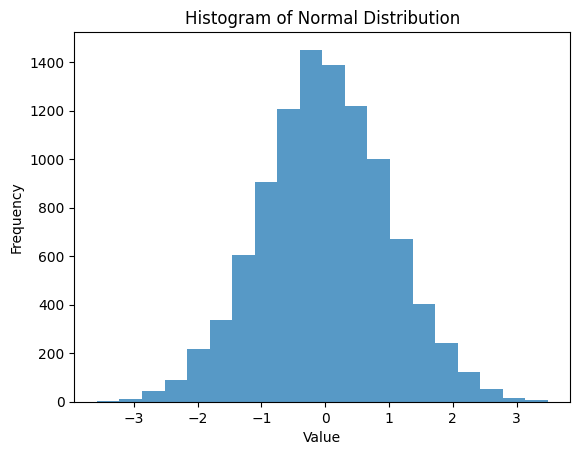

In [3]:
import matplotlib.pyplot as plot
plot.hist(sample, bins=20, alpha=0.75)
plot.title("Histogram of Normal Distribution")
plot.xlabel("Value")
plot.ylabel("Frequency")
plot.show()



## Data Exploration/Analysis
Plot the readings from that station over the course of a year

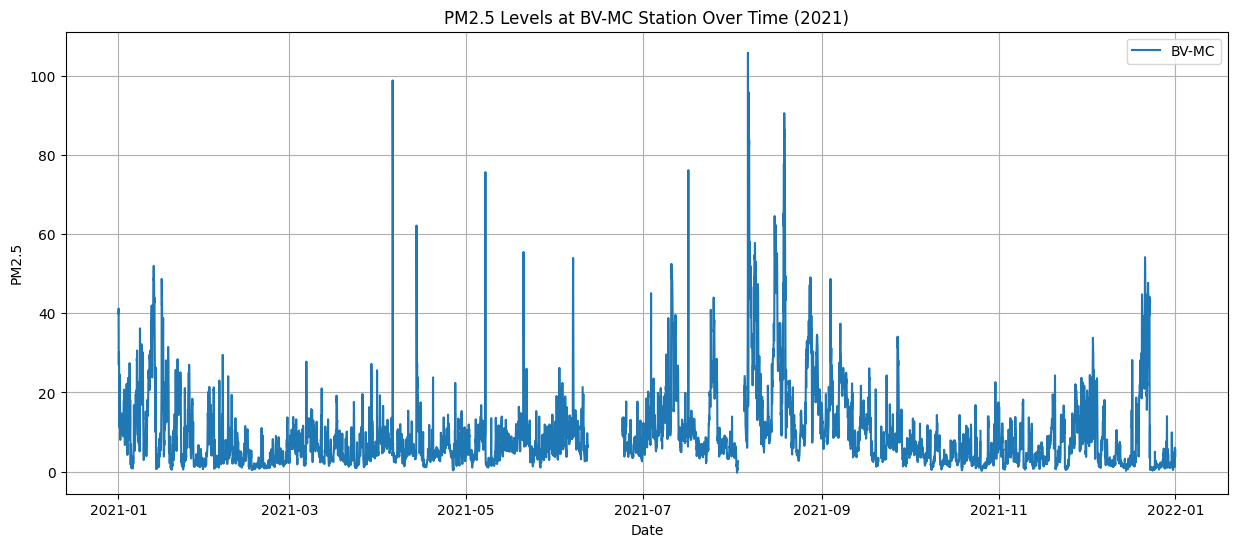

In [4]:
import pandas as pd
bvData = pd.read_csv("2021-PM2.5.csv", parse_dates=['Date'])

#we can also do df["Date"] = pd.to_datetime(df["Date"])

station = 'BV-MC'
plot.figure(figsize=(15, 6))
plot.plot(bvData['Date'], bvData[station], label=station)
plot.title(f"PM2.5 Levels at {station} Station Over Time (2021)")
plot.xlabel("Date")
plot.ylabel("PM2.5")
plot.grid(True)
plot.legend()
plot.show()


There isn't much that we can gain from this visualization. Even the station name is way to specific. All I can canther is that there was a range from about 0PM2.5 to over 105 PM2.5. There was also a period from right after june of 2021 to almost the end of june where no data was collected for the site.

Plot the mean pm2.5 level for each month using a bar chart.

/var/folders/g7/6tmkmhfx0ks5j72hk5_ty7rm0000gn/T/ipykernel_37041/3308166259.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthlyAverage = bvData.groupby('Month')[station].mean()


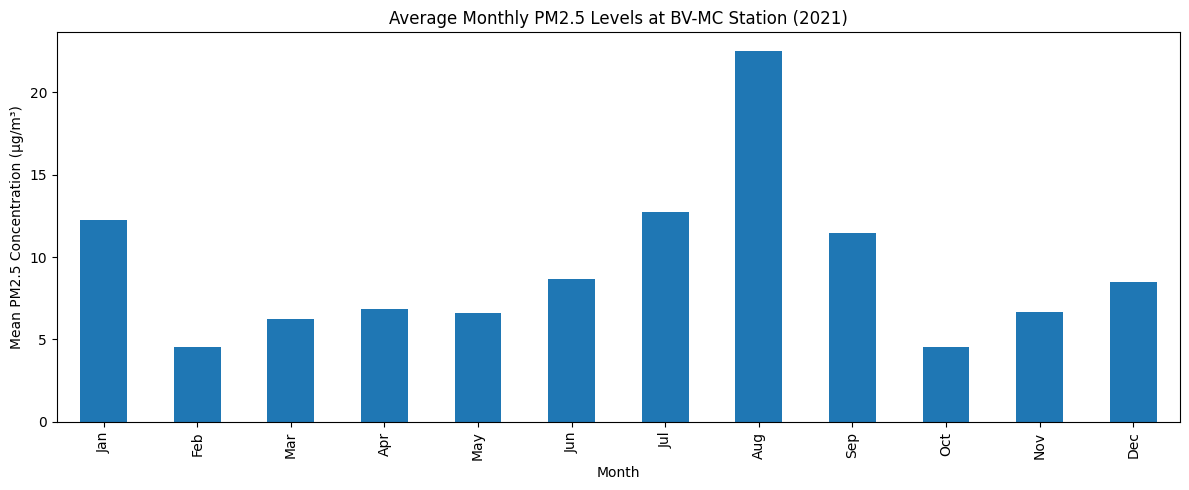

In [8]:
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plot

monthOrder = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Add ordered=True to preserve calendar order
monthCatType = CategoricalDtype(categories=monthOrder, ordered=True)

# Ensure Month column exists with 3-letter names
bvData['Month'] = bvData['Date'].dt.month_name().str[:3]
bvData['Month'] = bvData['Month'].astype(monthCatType)

# Group and sort
monthlyAverage = bvData.groupby('Month')[station].mean()

# Plot
monthlyAverage.plot(kind='bar', figsize=(12, 5))
plot.title(f"Average Monthly PM2.5 Levels at {station} Station (2021)")
plot.xlabel("Month")
plot.ylabel("Mean PM2.5 Concentration (µg/m³)")
plot.tight_layout()
plot.show()



This figure provides a better display for data visualization. From this image we can see that August obviously had the highest concentration on average in the BV county. We can also see that there is generally a relatively normal 'looking' distribution from feburary to january if we take january out of the picture for the 2021 records.

Next, group the data by time of day (by hour), and plot the mean pollution level for each hour. What insights can you draw from this view of the data?

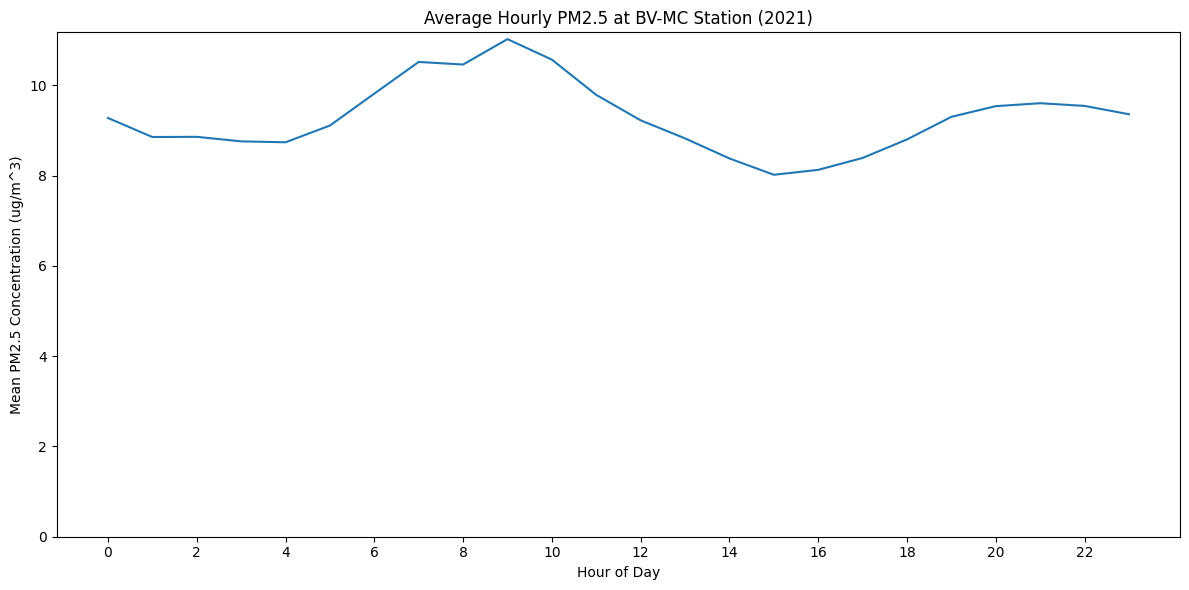

In [11]:
bvData['Hour'] = bvData['Date'].dt.hour

hourlyAvg = bvData.groupby('Hour')[station].mean()

# Plot
hourlyAvg.plot(figsize=(12, 6))
plot.title(f"Average Hourly PM2.5 at {station} Station (2021)")
plot.xlabel("Hour of Day")
plot.ylabel("Mean PM2.5 Concentration (ug/m^3)")
plot.ylim(bottom=0)
plot.xticks(ticks=range(0, 24, 2))
plot.tight_layout()
plot.show()

With the hourly average distribution we can see very clean differences is data. The line graph provides a further illustration of how different 10am is than 3pm on average for the entire year. Looking a this same exact distribution with a bar graph (which include a possible pm 2.5 of 0, which doesn't ever occur on average) makes the differences seem insignificant. With this line we can see that peaks for pollution in this county are around morning rush hour, which in this case seems to be approximately 830am.

 Use Box and Whisker plots of the monthly and hourly data groupings to provide a more complete view of the data. Does this view provide any additional insights?

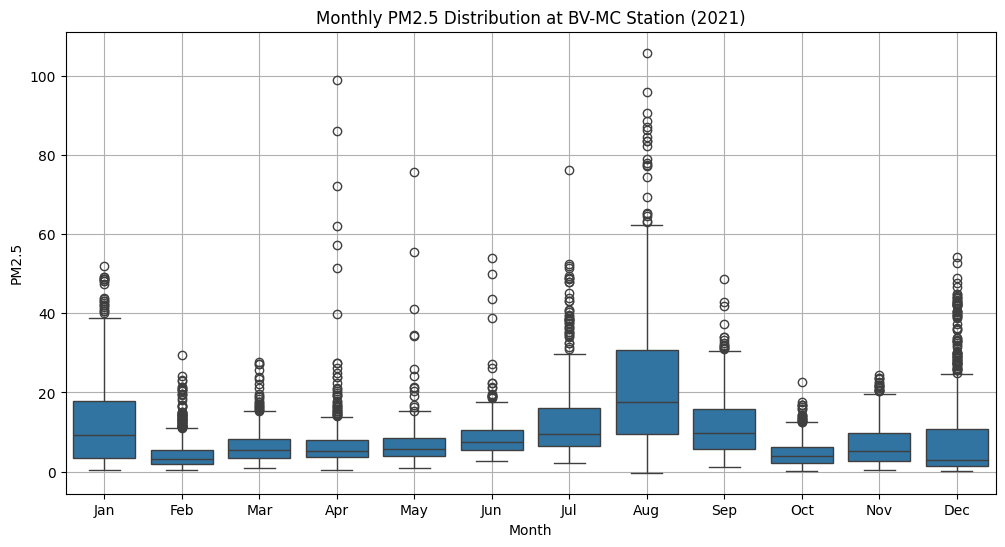

In [9]:
import seaborn as sns

plot.figure(figsize=(12, 6))
sns.boxplot(x='Month', y=station, data=bvData)
plot.title(f"Monthly PM2.5 Distribution at {station} Station (2021)")
plot.xlabel("Month")
plot.ylabel("PM2.5")
plot.grid(True)
plot.show()


Does this view provide any additional insights?

The scatterplots are a nice addition of information compared to the bar graphs and line graphs. We can see that in Feb, Mar, Apr, Oct the air qaulity was much more consistent. The quartiles were much closer together or condensed in Feb, Mar, Apr, Oct. In August, July and December we can see can see some every extreme outliers, this could indicate extreme weather events, we can also that in the same months the medians (horizontal lines inside the boxes) were not as close to the middle, indicating that the outliers had huge effect on the distribution of air quality levels.

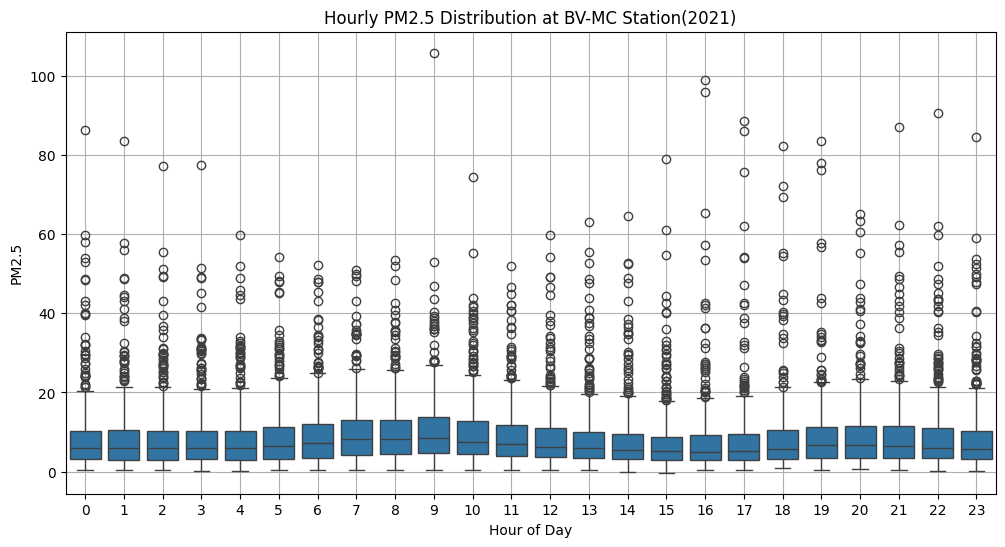

In [13]:
plot.figure(figsize=(12, 6))
sns.boxplot(x='Hour', y=station, data=bvData)
plot.title(f"Hourly PM2.5 Distribution at {station} Station(2021)")
plot.xlabel("Hour of Day")
plot.ylabel("PM2.5")
plot.grid(True)
plot.show()


Does this view provide any additional insights?

With the addition of the hourly box block we are provided more information. Again we can see that there are a lot of extreme outliers, however, this holds true for every hour of the day. This plot does provide a nice illustration of hours that have higher pollution, one example would be 9am, this appears to have the worst air quality, as well as the largest outlier and highest median, this suggests that there might have been something extreme like a major shut down in rush hour one day. This could provide me with the hypothesis that traffic especially rush hour may contribute significantly to pollution in BV, Utah.

